In [3]:
import pandas as pd

df = pd.read_csv("atm_cash_management_dataset.csv")

In [4]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [5]:
df

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,ATM_0041,2022-04-25,Monday,Morning,57450,9308,Standalone,0,0,112953,Rainy,5,44165
1,ATM_0007,2023-11-24,Friday,Morning,72845,17896,Supermarket,0,0,115348,Clear,0,41249
2,ATM_0014,2022-08-27,Saturday,Morning,42957,12712,Supermarket,0,0,90731,Cloudy,1,29901
3,ATM_0029,2023-08-27,Sunday,Evening,43014,1375,Mall,0,0,88754,Rainy,5,44155
4,ATM_0028,2022-12-15,Thursday,Evening,36379,2938,Bank Branch,0,0,129312,Snowy,0,29784
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5653,ATM_0029,2022-07-02,Saturday,Night,32027,3097,Standalone,0,0,96493,Clear,2,35148
5654,ATM_0050,2023-12-08,Friday,Afternoon,60120,4948,Mall,0,0,128933,Rainy,5,51927
5655,ATM_0036,2022-10-04,Tuesday,Evening,32551,10819,Mall,0,0,104519,Snowy,3,31127
5656,ATM_0010,2022-04-19,Tuesday,Night,52965,13372,Gas Station,0,0,107829,Rainy,2,35886


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Quarter"] = df["Date"].dt.quarter

In [8]:
categorical_columns = [
    "Day_of_Week",
    "Time_of_Day",
    "Location_Type",
    "Weather_Condition"
]

In [9]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [10]:
df_encoded.head()

,ATM_ID,Date,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Cash_Demand_Next_Day,Year,...,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Location_Type_Gas Station,Location_Type_Mall,Location_Type_Standalone,Location_Type_Supermarket,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Snowy
0,ATM_0041,2022-04-25,57450,9308,0,0,112953,5,44165,2022,...,False,True,False,False,False,True,False,False,True,False
1,ATM_0007,2023-11-24,72845,17896,0,0,115348,0,41249,2023,...,False,True,False,False,False,False,True,False,False,False
2,ATM_0014,2022-08-27,42957,12712,0,0,90731,1,29901,2022,...,False,True,False,False,False,False,True,True,False,False
3,ATM_0029,2023-08-27,43014,1375,0,0,88754,5,44155,2023,...,True,False,False,False,True,False,False,False,True,False
4,ATM_0028,2022-12-15,36379,2938,0,0,129312,0,29784,2022,...,True,False,False,False,False,False,False,False,False,True


In [11]:
y = df_encoded["Cash_Demand_Next_Day"]
y

0       44165
1       41249
2       29901
3       44155
4       29784
        ...  
5653    35148
5654    51927
5655    31127
5656    35886
5657    52971
Name: Cash_Demand_Next_Day, Length: 5658, dtype: int64

In [12]:
X = df_encoded.drop(
    columns=[
        "ATM_ID",
        "Date",
        "Cash_Demand_Next_Day"
    ]
)

In [13]:
X.shape

(5658, 26)

In [14]:
y.shape

(5658,)

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
    )

In [17]:
X_train.shape

(4526, 26)

In [18]:
X_test.shape

(1132, 26)

In [19]:
y_train.shape

(4526,)

In [20]:
y_test.shape

(1132,)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model = LinearRegression()

In [23]:
model.fit(X_train, y_train)

LinearRegression()

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred[:5]

array([44516.90279446, 71816.26553362, 43470.44099598, 30135.54820738,
       25779.59785336])

In [26]:
y_test.head()

3803    50335
5098    76882
3691    49730
1499    26431
3296    26694
Name: Cash_Demand_Next_Day, dtype: int64

In [27]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

0.8704592434444105


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5041.994842563429
RMSE: 6112.655900410188


In [29]:
from sklearn.ensemble import RandomForestRegressor

In [30]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [31]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [32]:
rf_pred = rf_model.predict(X_test)

In [33]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("R²:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

R²: 0.8579444698752847
MAE: 5238.808268551236
RMSE: 6401.117610825856


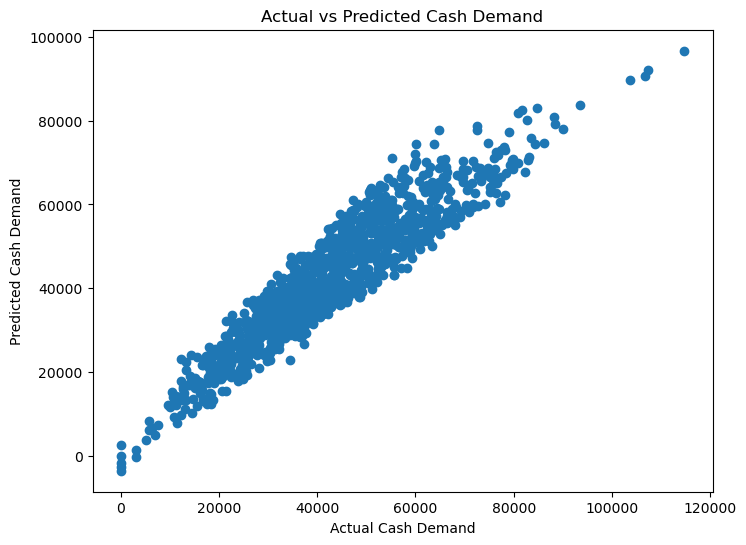

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Cash Demand")
plt.ylabel("Predicted Cash Demand")
plt.title("Actual vs Predicted Cash Demand")
plt.show()

In [35]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
3,Special_Event_Flag,7350.867783
2,Holiday_Flag,5479.400442
20,Location_Type_Mall,538.854126
23,Weather_Condition_Cloudy,493.229149
25,Weather_Condition_Snowy,448.624152
24,Weather_Condition_Rainy,397.699042
16,Time_of_Day_Evening,135.647615
21,Location_Type_Standalone,103.061091
12,Day_of_Week_Sunday,99.264492
10,Day_of_Week_Monday,24.187843


In [36]:
coefficients.sort_values(
    by="Coefficient"
).head(10)

,Feature,Coefficient
14,Day_of_Week_Tuesday,-363.575038
17,Time_of_Day_Morning,-324.936568
13,Day_of_Week_Thursday,-300.541937
19,Location_Type_Gas Station,-216.416351
22,Location_Type_Supermarket,-154.435660
15,Day_of_Week_Wednesday,-123.696055
5,Nearby_Competitor_ATMs,-50.512085
6,Year,-39.036859
9,Quarter,-15.887422
8,Day,-12.130307


In [37]:
X.columns

Index(['Total_Withdrawals', 'Total_Deposits', 'Holiday_Flag',
       'Special_Event_Flag', 'Previous_Day_Cash_Level',
       'Nearby_Competitor_ATMs', 'Year', 'Month', 'Day', 'Quarter',
       'Day_of_Week_Monday', 'Day_of_Week_Saturday', 'Day_of_Week_Sunday',
       'Day_of_Week_Thursday', 'Day_of_Week_Tuesday', 'Day_of_Week_Wednesday',
       'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night',
       'Location_Type_Gas Station', 'Location_Type_Mall',
       'Location_Type_Standalone', 'Location_Type_Supermarket',
       'Weather_Condition_Cloudy', 'Weather_Condition_Rainy',
       'Weather_Condition_Snowy'],
      dtype='object')

In [38]:
X.dtypes

Total_Withdrawals            int64
Total_Deposits               int64
Holiday_Flag                 int64
Special_Event_Flag           int64
Previous_Day_Cash_Level      int64
Nearby_Competitor_ATMs       int64
Year                         int32
Month                        int32
Day                          int32
Quarter                      int32
Day_of_Week_Monday            bool
Day_of_Week_Saturday          bool
Day_of_Week_Sunday            bool
Day_of_Week_Thursday          bool
Day_of_Week_Tuesday           bool
Day_of_Week_Wednesday         bool
Time_of_Day_Evening           bool
Time_of_Day_Morning           bool
Time_of_Day_Night             bool
Location_Type_Gas Station     bool
Location_Type_Mall            bool
Location_Type_Standalone      bool
Location_Type_Supermarket     bool
Weather_Condition_Cloudy      bool
Weather_Condition_Rainy       bool
Weather_Condition_Snowy       bool
dtype: object

In [39]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5658 entries, 0 to 5657
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Total_Withdrawals          5658 non-null   int64
 1   Total_Deposits             5658 non-null   int64
 2   Holiday_Flag               5658 non-null   int64
 3   Special_Event_Flag         5658 non-null   int64
 4   Previous_Day_Cash_Level    5658 non-null   int64
 5   Nearby_Competitor_ATMs     5658 non-null   int64
 6   Year                       5658 non-null   int32
 7   Month                      5658 non-null   int32
 8   Day                        5658 non-null   int32
 9   Quarter                    5658 non-null   int32
 10  Day_of_Week_Monday         5658 non-null   bool 
 11  Day_of_Week_Saturday       5658 non-null   bool 
 12  Day_of_Week_Sunday         5658 non-null   bool 
 13  Day_of_Week_Thursday       5658 non-null   bool 
 14  Day_of_Week_Tuesday     

In [40]:
import xgboost
print(xgboost.__version__)

3.0.5


In [41]:
from xgboost import XGBRegressor

In [42]:
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

In [43]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
xgb_pred = xgb_model.predict(X_test)

In [45]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("R²:", xgb_r2)
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)

R²: 0.8633423447608948
MAE: 5107.2939453125
RMSE: 6278.323980171778


In [46]:
import shap

print(shap.__version__)

0.52.0


In [47]:
!pip install shap

In [48]:
explainer = shap.Explainer(model, X_train)

Background dataset has 4526 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4526 when initializing the masker.


In [49]:
shap_values = explainer(X_test)

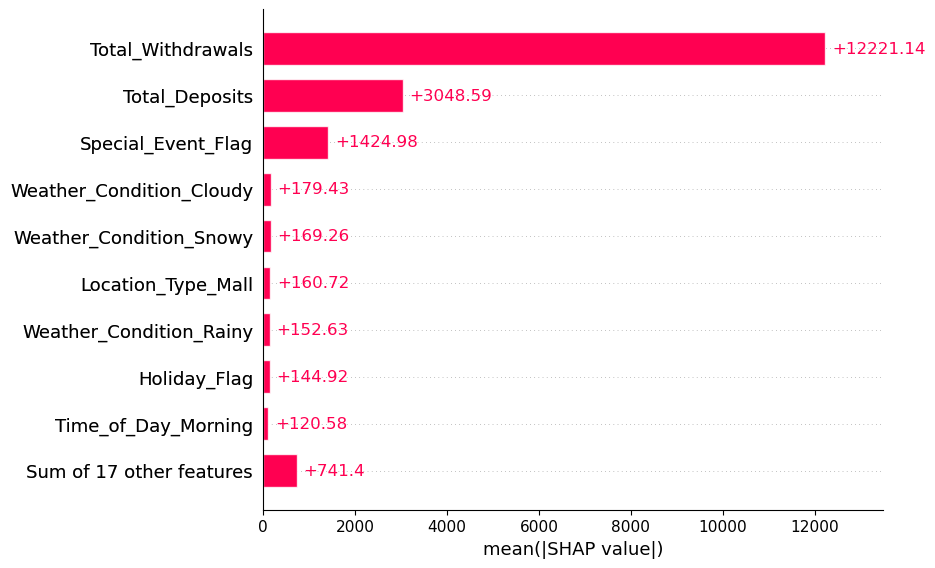

In [50]:
shap.plots.bar(shap_values)

In [51]:

import joblib

joblib.dump(model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

In [52]:
df_encoded.to_csv("atm_encoded_dataset.csv", index=False)

In [53]:
df_encoded.shape


(5658, 29)

In [54]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, random_state=42)
}

print("5-Fold Cross-Validation R² Scores\n")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="r2")
    print(f"{name:20s}  mean={scores.mean():.4f}  std={scores.std():.4f}")

5-Fold Cross-Validation R² Scores

Linear Regression     mean=0.8637  std=0.0064
Random Forest         mean=0.8491  std=0.0044
XGBoost               mean=0.8259  std=0.0076


In [56]:
from sklearn.model_selection import GridSearchCV

# Tune Random Forest
rf_params = {
    "n_estimators":  [50, 100, 200],
    "max_depth":     [3, 5, 10, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features":  ["sqrt", "log2", 0.5]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params, cv=5, scoring="r2", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Best RF R²:", rf_grid.best_score_)
print("Best RF params:", rf_grid.best_params_)

# Tune XGBoost
xgb_params = {
    "n_estimators":  [50, 100, 200],
    "max_depth":     [3, 4, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample":     [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_params, cv=5, scoring="r2", n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
print("Best XGB R²:", xgb_grid.best_score_)
print("Best XGB params:", xgb_grid.best_params_)

Best RF R²: 0.8503860673107523
Best RF params: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 200}
Best XGB R²: 0.8566329836845398
Best XGB params: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
